# Overall-Optimal DRL Stress Notebook

This notebook is a clean, separate workspace for reproducible DRL stress experiments.

It focuses on:
- starvation-aware training
- guarded-policy controls and override budgets
- parity baselines under shared stress conditions
- 30-seed confidence reporting and hard-slice significance testing

## 1) Environment Setup and Reproducibility

Import dependencies, define constants, and lock random seeds.

In [1]:
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288
CAPACITY = 8

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4)

OVERALL_WEIGHTS = {
    "carbon": 0.40,
    "jct": 0.20,
    "tail": 0.20,
    "preempt": 0.10,
    "starvation": 0.10,
}

WEIGHT_CANDIDATES = [
    {"carbon": 0.45, "jct": 0.20, "tail": 0.15, "preempt": 0.10, "starvation": 0.10},
    {"carbon": 0.40, "jct": 0.20, "tail": 0.20, "preempt": 0.10, "starvation": 0.10},
    {"carbon": 0.35, "jct": 0.20, "tail": 0.25, "preempt": 0.10, "starvation": 0.10},
    {"carbon": 0.35, "jct": 0.25, "tail": 0.20, "preempt": 0.10, "starvation": 0.10},
]

print("Setup complete. Seed:", SEED)

Setup complete. Seed: 42


## 2) Load Prior Outputs and Validate Dependencies

Load saved CSV artifacts when available and validate expected columns early.

In [2]:
def resolve_data_file(file_name: str) -> Path:
    candidates = [
        Path("../data") / file_name,
        Path("../../Eco-Cloud/data") / file_name,
        Path("data") / file_name,
        Path("Eco-Cloud/data") / file_name,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {file_name}. Checked: {candidates}")


def load_csv_optional(file_name: str) -> pd.DataFrame | None:
    try:
        return pd.read_csv(resolve_data_file(file_name))
    except FileNotFoundError:
        return None


def require_columns(df: pd.DataFrame, columns: set[str], label: str):
    missing = columns - set(df.columns)
    if missing:
        raise ValueError(f"{label} missing required columns: {sorted(missing)}")


prior_summary = load_csv_optional("parity_30seed_ci_summary.csv")
prior_detail = load_csv_optional("parity_30seed_detail.csv")

if prior_summary is not None:
    require_columns(
        prior_summary,
        {"policy", "noise_pct", "congestion", "capacity"},
        "parity_30seed_ci_summary.csv",
    )
if prior_detail is not None:
    require_columns(
        prior_detail,
        {"policy", "seed", "carbon_kg", "avg_jct_h", "jobs_completed"},
        "parity_30seed_detail.csv",
    )

print("Found prior summary:", prior_summary is not None)
print("Found prior detail:", prior_detail is not None)

Found prior summary: True
Found prior detail: True


## 3) Dataset Loading and Preprocessing Utilities

Load clean_dataset.csv and create robust preprocessing helpers for duration, energy, and power proxy features.

In [3]:
def load_clean_dataset() -> pd.DataFrame:
    candidates = [
        Path("../../clean_dataset.csv"),
        Path("../clean_dataset.csv"),
        Path("clean_dataset.csv"),
    ]
    dataset_path = next((p for p in candidates if p.exists()), None)
    if dataset_path is None:
        raise FileNotFoundError(f"Could not locate clean_dataset.csv. Checked: {candidates}")

    df = pd.read_csv(dataset_path)
    req = {"start_time", "duration", "energy", "plan_cpu", "job_name", "task_name"}
    require_columns(df, req, "clean_dataset.csv")

    df = df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
    df["duration"] = df["duration"].clip(lower=1)
    df["energy"] = df["energy"].clip(lower=1e-6)
    df["power_proxy"] = df["energy"] / df["duration"]
    return df


raw_df = load_clean_dataset()
print(f"Loaded rows: {len(raw_df):,}")
display(raw_df[["duration", "energy", "plan_cpu", "power_proxy"]].describe().round(3))

Loaded rows: 46,533


,duration,energy,plan_cpu,power_proxy
count,46533.000,46533.000,46533.000,46533.000
mean,59.846,4.353,83.826,0.084
std,129.145,11.869,62.826,0.063
min,1.000,0.020,5.000,0.005
25%,3.000,0.200,50.000,0.050
50%,9.000,0.600,100.000,0.100
75%,43.000,2.940,100.000,0.100
max,985.000,566.300,700.000,0.700


## 4) Simulator Core Reuse (Job, Carbon, Environment, State Discretization)

Define workload builders, carbon curves, workload shocks, environment dynamics, and state discretization for tabular control.

In [4]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float


def make_workload(congestion: str, horizon_steps: int, rng: np.random.Generator) -> list[Job]:
    rates = {"light": 0.20, "moderate": 0.38, "high": 0.55}
    rate = rates[congestion]
    jobs = []
    jid = 0
    for step in range(horizon_steps):
        if rng.random() < rate:
            duration = int(rng.integers(6, 40))
            power = float(rng.choice([1.2, 2.0, 3.2], p=[0.35, 0.45, 0.20]))
            jobs.append(Job(job_id=jid, submit_step=step, duration_steps=duration, power_kw=power))
            jid += 1
    if not jobs:
        jobs.append(Job(job_id=0, submit_step=0, duration_steps=10, power_kw=2.0))
    return jobs


def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 80, "moderate": 150, "high": 240}
    n = jobs_per_regime[congestion]
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()

    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).astype(int)
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 96)

    q1 = df["power_proxy"].quantile(0.33)
    q2 = df["power_proxy"].quantile(0.66)

    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2

    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)

    jobs = []
    for i, row in enumerate(sampled.itertuples(index=False)):
        jobs.append(
            Job(
                job_id=i,
                submit_step=int(row.submit_step),
                duration_steps=int(row.duration_steps),
                power_kw=float(row.power_kw),
            )
        )
    return jobs


def build_jobs(congestion: str, horizon_steps: int, rng: np.random.Generator, source: str, df: pd.DataFrame) -> list[Job]:
    if source == "synthetic":
        return make_workload(congestion, horizon_steps, rng)
    if source == "dataset":
        return make_workload_from_dataset(congestion, horizon_steps, rng, df)
    raise ValueError(f"Unknown source: {source}")


def make_carbon_curve(horizon_steps: int, noise_pct: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(0.0, (noise_pct / 100.0) * base)
    return np.clip(base + noise, 80, 650).astype(float)


def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    curve = make_carbon_curve(horizon_steps=horizon_steps, noise_pct=noise_pct, rng=rng).copy()
    n_spikes = max(1, int(0.03 * horizon_steps))
    n_dips = max(1, int(0.02 * horizon_steps))
    spike_idx = rng.choice(np.arange(horizon_steps), size=n_spikes, replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=n_dips, replace=False)
    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))
    return np.clip(curve, 80, 650)


def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    if not jobs:
        return jobs

    shocked = []
    burst_center = int(rng.integers(int(0.25 * horizon_steps), int(0.75 * horizon_steps)))
    burst_half_window = 12

    for j in jobs:
        submit_step = j.submit_step
        duration_steps = j.duration_steps
        power_kw = j.power_kw

        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.5, 2.8), 3, 120))
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.2), 1.0, 3.8))

        shocked.append(Job(job_id=j.job_id, submit_step=submit_step, duration_steps=duration_steps, power_kw=power_kw))

    return shocked

In [5]:
class SimpleClusterEnv:
    def __init__(
        self,
        jobs: list[Job],
        carbon_curve: np.ndarray,
        capacity: int = 8,
        reward_weights: dict | None = None,
    ):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.weights = reward_weights or OVERALL_WEIGHTS
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()

        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.total_starvation_penalty = 0.0

        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / max(1, self.capacity)
        load = min(queue_len / (2 * max(1, self.capacity)), 1.0)

        if self.waiting:
            ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            p90_wait = float(np.percentile(ages, 90)) / 96.0
        else:
            p90_wait = 0.0

        active = self._active_jobs()
        if active:
            long_ratio = np.mean([1.0 if self.remaining[j] >= 24 else 0.0 for j in active])
        else:
            long_ratio = 0.0

        return np.array([ci_norm, load, util, min(1.0, p90_wait), float(long_ratio)], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]

        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        elif policy_name == "aged_srtf":
            ranked = sorted(
                active,
                key=lambda jid: (
                    self.remaining[jid] - 0.15 * max(0, self.step_idx - self.submit[jid]),
                    self.submit[jid],
                ),
            )
        elif policy_name == "carbon_guarded_short":
            if ci_now >= float(np.quantile(self.curve, 0.85)):
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()

        action_map = {
            0: "fcfs",
            1: "carbon",
            2: "srtf",
            3: "aged_srtf",
            4: "carbon_guarded_short",
        }
        selected = set(self._policy_rank(action_map[action_idx]))

        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions

        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                self.running.discard(jid)
                self.waiting.add(jid)

        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0

        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)

        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg

        if self.waiting:
            wait_ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            tail_wait = float(np.percentile(wait_ages, 90))
            starvation_ratio = float(np.mean([1.0 if w >= 18 else 0.0 for w in wait_ages]))
        else:
            tail_wait = 0.0
            starvation_ratio = 0.0

        self.total_starvation_penalty += starvation_ratio

        carbon_penalty = step_carbon_kg
        jct_penalty = len(self.waiting) + 0.25 * len(self.running)
        tail_penalty = tail_wait
        preempt_penalty = preemptions / max(1, self.capacity)

        cost = (
            self.weights.get("carbon", 0.0) * carbon_penalty
            + self.weights.get("jct", 0.0) * jct_penalty
            + self.weights.get("tail", 0.0) * tail_penalty
            + self.weights.get("preempt", 0.0) * preempt_penalty
            + self.weights.get("starvation", 0.0) * starvation_ratio
        )
        reward = -cost

        self.prev_running = set(self.running)
        self.step_idx += 1

        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = len(self.waiting) == 0 and len(self.running) == 0
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)

        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)

        if completed_jcts:
            avg_jct_h = float(np.mean(completed_jcts))
            tail_jct_h = float(np.percentile(completed_jcts, 95))
        else:
            avg_jct_h = np.nan
            tail_jct_h = np.nan

        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
            "starvation_penalty": self.total_starvation_penalty / max(1, self.max_step),
        }


def discretize_state(state_vec: np.ndarray):
    ci, load, util, p90_wait, long_ratio = state_vec
    ci_bin = min(int(ci * 4), 3)
    load_bin = min(int(load * 4), 3)
    util_bin = 0 if util < 0.5 else 1
    wait_bin = min(int(p90_wait * 3), 2)
    long_bin = min(int(long_ratio * 3), 2)
    return (ci_bin, load_bin, util_bin, wait_bin, long_bin)

## 5) Starvation-Aware Reward Configuration and Curriculum Training

Train tabular Q-learning over congestion stages with explicit starvation-tail terms in the reward.

In [6]:
def train_q_learning_curriculum(
    episodes_per_stage: int = 80,
    alpha: float = 0.12,
    gamma: float = 0.97,
    source: str = "dataset",
    df: pd.DataFrame | None = None,
    reward_weights: dict | None = None,
):
    if source == "dataset" and df is None:
        raise ValueError("df is required when source='dataset'")

    q = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    stages = [("light", 5.0), ("moderate", 10.0), ("high", 15.0)]
    history = []

    total_eps = episodes_per_stage * len(stages)
    ep_index = 0

    for congestion, noise in stages:
        for _ in range(episodes_per_stage):
            eps = 0.05 + (1.0 - 0.05) * np.exp(-4.0 * ep_index / max(1, total_eps))
            rng = np.random.default_rng(20_000 + ep_index)

            jobs = build_jobs(congestion, HORIZON_STEPS, rng, source, df)
            curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
            env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY, reward_weights=reward_weights or OVERALL_WEIGHTS)

            state = env.reset()
            done = False
            ep_reward = 0.0

            while not done:
                s = discretize_state(state)
                if rng.random() < eps:
                    action = int(rng.integers(0, 5))
                else:
                    action = int(np.argmax(q[s]))

                next_state, reward, done, _ = env.step(action)
                ns = discretize_state(next_state)

                td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
                q[s + (action,)] += alpha * (td_target - q[s + (action,)])

                ep_reward += reward
                state = next_state

            m = env.metrics()
            history.append(
                {
                    "episode": ep_index,
                    "stage": congestion,
                    "noise_pct": noise,
                    "reward": ep_reward,
                    "carbon_kg": m["carbon_kg"],
                    "avg_jct_h": m["avg_jct_h"],
                }
            )
            ep_index += 1

    return q, pd.DataFrame(history)


STARVATION_REWARD_CFG = {"carbon": 0.35, "jct": 0.20, "tail": 0.25, "preempt": 0.10, "starvation": 0.10}
q_curr, hist_curr = train_q_learning_curriculum(
    episodes_per_stage=60,
    source="dataset",
    df=raw_df,
    reward_weights=STARVATION_REWARD_CFG,
)

display(hist_curr.groupby("stage", as_index=False)[["reward", "carbon_kg", "avg_jct_h"]].mean().round(4))

,stage,reward,carbon_kg,avg_jct_h
0,high,-3036.6198,75.2315,1.4138
1,light,-64.3766,32.7344,0.9058
2,moderate,-584.2777,57.8929,0.9558


## 6) Domain-Randomized Stress Training

Train across randomized source, congestion, noise, and capacity settings to improve out-of-distribution robustness.

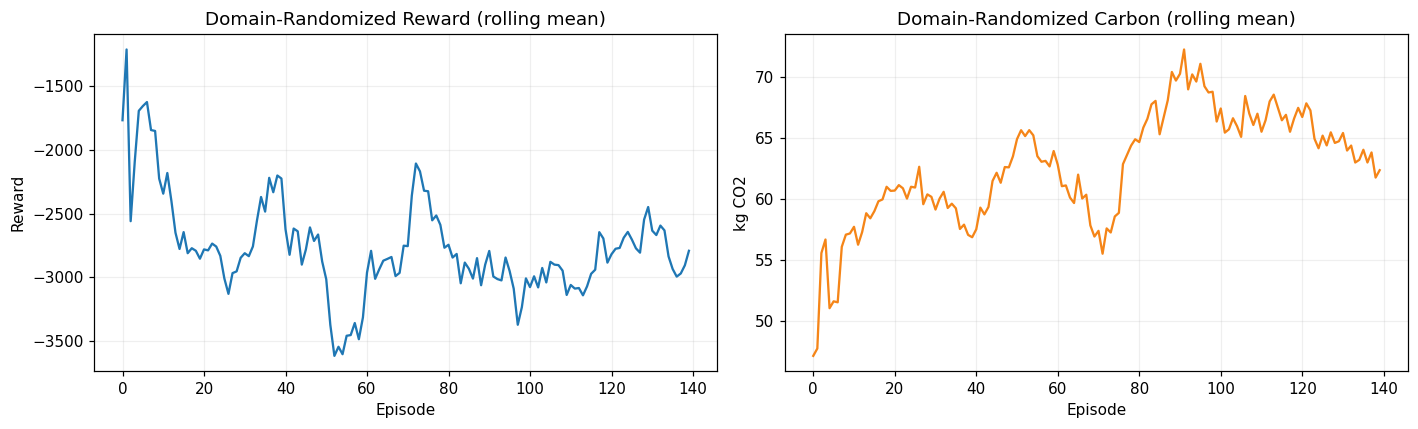

In [7]:
def train_q_learning_domain_randomized(
    episodes: int = 180,
    alpha: float = 0.12,
    gamma: float = 0.97,
    reward_weights: dict | None = None,
    df: pd.DataFrame | None = None,
):
    if df is None:
        raise ValueError("df is required")

    q = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    history = []

    for ep in range(episodes):
        rng = np.random.default_rng(70_000 + ep)
        eps = 0.05 + (1.0 - 0.05) * np.exp(-4.0 * ep / max(1, episodes))

        source = "dataset" if rng.random() < 0.75 else "synthetic"
        congestion = str(rng.choice(["light", "moderate", "high"], p=[0.20, 0.45, 0.35]))
        noise = float(rng.choice([5.0, 10.0, 15.0, 20.0, 30.0], p=[0.15, 0.25, 0.25, 0.20, 0.15]))
        capacity = int(rng.choice([6, 8, 10], p=[0.35, 0.50, 0.15]))

        jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source=source, df=df)
        jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
        curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=reward_weights or OVERALL_WEIGHTS)
        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            if rng.random() < eps:
                action = int(rng.integers(0, 5))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)
            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        history.append(
            {
                "episode": ep,
                "source": source,
                "congestion": congestion,
                "noise_pct": noise,
                "capacity": capacity,
                "reward": ep_reward,
                "carbon_kg": m["carbon_kg"],
                "avg_jct_h": m["avg_jct_h"],
            }
        )

    return q, pd.DataFrame(history)


q_real, hist_real = train_q_learning_domain_randomized(
    episodes=140,
    reward_weights=STARVATION_REWARD_CFG,
    df=raw_df,
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), dpi=110)
ax[0].plot(hist_real["episode"], hist_real["reward"].rolling(20, min_periods=1).mean())
ax[0].set_title("Domain-Randomized Reward (rolling mean)")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Reward")
ax[0].grid(alpha=0.2)

ax[1].plot(hist_real["episode"], hist_real["carbon_kg"].rolling(20, min_periods=1).mean(), color="#F58518")
ax[1].set_title("Domain-Randomized Carbon (rolling mean)")
ax[1].set_xlabel("Episode")
ax[1].set_ylabel("kg CO2")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7) Guarded DRL Policy and Override Budget Controls

Apply guarded inference under dirty-grid conditions and evaluate threshold/budget sweeps.

In [8]:
def run_policy_inference(
    policy_name: str,
    seed: int,
    q_table: np.ndarray | None,
    df: pd.DataFrame,
    noise_pct: float,
    congestion: str,
    capacity: int,
    dirty_quantile: float = 0.90,
    guard_budget_per_hour: int | None = None,
):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=STARVATION_REWARD_CFG)
    state = env.reset()
    done = False
    fixed_map = {"fcfs": 0, "carbon": 1, "srtf": 2}

    dirty_threshold = float(np.quantile(curve, dirty_quantile))
    steps_per_hour = max(1, int(round(60 / STEP_MINUTES)))
    current_window = 0
    overrides_this_window = 0

    while not done:
        if policy_name in fixed_map:
            action = fixed_map[policy_name]
        elif policy_name in {"q_overall", "q_overall_guarded", "q_overall_guarded_budget"}:
            if q_table is None:
                raise ValueError("q_table is required for q_overall policies")
            action = int(np.argmax(q_table[discretize_state(state)]))

            if policy_name != "q_overall":
                window = env.step_idx // steps_per_hour
                if window != current_window:
                    current_window = window
                    overrides_this_window = 0

                ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
                can_override = True
                if guard_budget_per_hour is not None:
                    can_override = overrides_this_window < guard_budget_per_hour

                if ci_now >= dirty_threshold and can_override:
                    action = 1
                    overrides_this_window += 1
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update(
        {
            "policy": policy_name,
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "seed": seed,
            "dirty_quantile": dirty_quantile,
            "guard_budget_per_hour": guard_budget_per_hour,
        }
    )
    return out


rows_q = []
for q in [0.60, 0.70, 0.80, 0.90]:
    for seed in range(12):
        for noise in [15.0, 20.0]:
            for cong in ["moderate", "high"]:
                for cap in [6, 8]:
                    rows_q.append(
                        run_policy_inference(
                            policy_name="q_overall_guarded",
                            seed=seed,
                            q_table=q_real,
                            df=raw_df,
                            noise_pct=noise,
                            congestion=cong,
                            capacity=cap,
                            dirty_quantile=q,
                        )
                    )

q_sweep = pd.DataFrame(rows_q)
q_summary = (
    q_sweep.groupby(["dirty_quantile", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        carbon_kg=("carbon_kg", "mean"),
        avg_jct_h=("avg_jct_h", "mean"),
        tail_jct_h=("tail_jct_h", "mean"),
        preemptions=("preemptions", "mean"),
        jobs_completed=("jobs_completed", "mean"),
    )
)
q_summary["carbon_per_completed_job"] = q_summary["carbon_kg"] / q_summary["jobs_completed"].clip(lower=1)
q_summary["tradeoff_score"] = 0.6 * q_summary["carbon_per_completed_job"] + 0.4 * q_summary["avg_jct_h"]
best_quantile = float(q_summary.sort_values("tradeoff_score").iloc[0]["dirty_quantile"])

rows_b = []
for budget in [4, 8, 12]:
    for seed in range(12):
        for noise in [15.0, 20.0]:
            for cong in ["moderate", "high"]:
                for cap in [6, 8]:
                    rows_b.append(
                        run_policy_inference(
                            policy_name="q_overall_guarded_budget",
                            seed=seed,
                            q_table=q_real,
                            df=raw_df,
                            noise_pct=noise,
                            congestion=cong,
                            capacity=cap,
                            dirty_quantile=best_quantile,
                            guard_budget_per_hour=budget,
                        )
                    )

budget_df = pd.DataFrame(rows_b)
budget_summary = (
    budget_df.groupby(["guard_budget_per_hour", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        carbon_kg=("carbon_kg", "mean"),
        avg_jct_h=("avg_jct_h", "mean"),
        tail_jct_h=("tail_jct_h", "mean"),
        preemptions=("preemptions", "mean"),
        jobs_completed=("jobs_completed", "mean"),
    )
)
budget_summary["carbon_per_completed_job"] = budget_summary["carbon_kg"] / budget_summary["jobs_completed"].clip(lower=1)
budget_summary["tradeoff_score"] = 0.6 * budget_summary["carbon_per_completed_job"] + 0.4 * budget_summary["avg_jct_h"]

print("Best guardrail quantile:", best_quantile)
display(q_summary.sort_values(["noise_pct", "congestion", "capacity", "tradeoff_score"]).head(20).round(4))
display(budget_summary.sort_values(["noise_pct", "congestion", "capacity", "tradeoff_score"]).head(20).round(4))

Best guardrail quantile: 0.9


,dirty_quantile,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed,carbon_per_completed_job,tradeoff_score
24,0.9,15.0,high,6,56.4071,2.2017,7.3962,319.0000,196.1667,0.2875,1.0532
16,0.8,15.0,high,6,55.1570,2.2888,8.0122,306.1667,197.0000,0.2800,1.0835
8,0.7,15.0,high,6,54.4210,2.7690,9.2795,298.2500,189.3333,0.2874,1.2801
0,0.6,15.0,high,6,54.4816,3.5816,10.6243,267.2500,157.9167,0.3450,1.6396
25,0.9,15.0,high,8,71.0956,1.9239,6.7285,368.5833,204.3333,0.3479,0.9783
17,0.8,15.0,high,8,69.9183,2.0094,7.1142,337.5000,205.7500,0.3398,1.0077
9,0.7,15.0,high,8,68.7329,2.2511,7.5215,319.7500,204.7500,0.3357,1.1019
1,0.6,15.0,high,8,68.4919,2.6050,8.1344,282.0000,198.5000,0.3450,1.2490
18,0.8,15.0,moderate,6,47.3926,1.7778,6.3434,195.2500,133.0000,0.3563,0.9249
26,0.9,15.0,moderate,6,47.9154,1.7968,6.5875,198.8333,132.6667,0.3612,0.9354


,guard_budget_per_hour,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed,carbon_per_completed_job,tradeoff_score
0,4,15.0,high,6,56.5626,2.1730,7.1674,310.0833,196.0000,0.2886,1.0424
8,8,15.0,high,6,56.4071,2.2017,7.3962,319.0000,196.1667,0.2875,1.0532
16,12,15.0,high,6,56.4071,2.2017,7.3962,319.0000,196.1667,0.2875,1.0532
1,4,15.0,high,8,71.3086,1.9134,6.7608,362.5833,204.6667,0.3484,0.9744
9,8,15.0,high,8,71.0956,1.9239,6.7285,368.5833,204.3333,0.3479,0.9783
17,12,15.0,high,8,71.0956,1.9239,6.7285,368.5833,204.3333,0.3479,0.9783
2,4,15.0,moderate,6,47.9102,1.7366,6.4809,191.4167,132.5000,0.3616,0.9116
10,8,15.0,moderate,6,47.9154,1.7968,6.5875,198.8333,132.6667,0.3612,0.9354
18,12,15.0,moderate,6,47.9154,1.7968,6.5875,198.8333,132.6667,0.3612,0.9354
11,8,15.0,moderate,8,56.5805,1.5331,5.7597,166.3333,140.5833,0.4025,0.8547


## 8) Parity Baselines (FCFS, Carbon Heuristic, SRTF, LAS/EcoVisor/GAIA Proxies)

Evaluate all policies under identical seeds and stress settings for fair comparison.

In [9]:
def simulate_with_priority_policy(jobs: list[Job], curve: np.ndarray, capacity: int, rank_fn):
    jobs_map = {j.job_id: j for j in jobs}
    job_order = sorted(jobs, key=lambda x: x.submit_step)
    submit = {jid: jobs_map[jid].submit_step for jid in jobs_map}
    remaining = {jid: jobs_map[jid].duration_steps for jid in jobs_map}
    attained = {jid: 0 for jid in jobs_map}

    finish = {}
    waiting = set()
    running = set()
    prev_running = set()
    arrival_ptr = 0

    total_carbon_kg = 0.0
    total_preemptions = 0
    total_wait_steps = 0

    for step_idx in range(len(curve)):
        while arrival_ptr < len(job_order) and job_order[arrival_ptr].submit_step <= step_idx:
            waiting.add(job_order[arrival_ptr].job_id)
            arrival_ptr += 1

        active = [jid for jid in jobs_map if jid not in finish and submit[jid] <= step_idx]
        if active:
            ranked = rank_fn(active, step_idx, remaining, attained, submit, jobs_map, curve)
            selected = set(ranked[:capacity])
        else:
            selected = set()

        preemptions = len(prev_running - selected)
        total_preemptions += preemptions

        running = set(selected)
        waiting = set(active) - running

        ci = curve[min(step_idx, len(curve) - 1)]
        finished_now = []

        for jid in list(running):
            remaining[jid] -= 1
            attained[jid] += 1
            total_carbon_kg += (jobs_map[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            finish[jid] = step_idx
            running.discard(jid)
            waiting.discard(jid)

        total_wait_steps += len(waiting)
        prev_running = set(running)

        no_future = arrival_ptr >= len(job_order)
        no_active = len(waiting) == 0 and len(running) == 0
        if no_future and no_active:
            break

    completed_jcts = [max(1, finish[j] - submit[j] + 1) * STEP_HOURS for j in finish]
    return {
        "jobs_total": len(jobs_map),
        "jobs_completed": len(finish),
        "carbon_kg": total_carbon_kg,
        "avg_jct_h": float(np.mean(completed_jcts)) if completed_jcts else np.nan,
        "tail_jct_h": float(np.percentile(completed_jcts, 95)) if completed_jcts else np.nan,
        "preemptions": total_preemptions,
        "avg_wait_h": (total_wait_steps * STEP_HOURS) / max(1, len(jobs_map)),
        "starvation_penalty": np.nan,
    }


def rank_las_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    return sorted(active, key=lambda jid: (attained[jid], remaining[jid], submit[jid], jid))


def rank_ecovisor_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    ci = curve[min(step_idx, len(curve) - 1)]
    ci_norm = (ci - 80) / (650 - 80)

    def score(jid):
        wait_age = max(0, step_idx - submit[jid] - attained[jid])
        power_term = ci_norm * jobs_map[jid].power_kw
        rem_term = remaining[jid] / 96.0
        return (0.65 * power_term + 0.25 * rem_term - 0.10 * (wait_age / 24.0), submit[jid], jid)

    return sorted(active, key=score)


def rank_gaia_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    ci_now = curve[min(step_idx, len(curve) - 1)]
    future_avg = float(np.mean(curve[step_idx : min(len(curve), step_idx + 12)]))

    if future_avg > ci_now * 1.02:
        return sorted(active, key=lambda jid: (-jobs_map[jid].power_kw, remaining[jid], submit[jid], jid))
    if future_avg < ci_now * 0.98:
        return sorted(active, key=lambda jid: (jobs_map[jid].power_kw, remaining[jid], submit[jid], jid))
    return sorted(active, key=lambda jid: (remaining[jid], jobs_map[jid].power_kw, submit[jid], jid))


def run_policy_proxy(policy_name: str, seed: int, df: pd.DataFrame, noise_pct: float, congestion: str, capacity: int):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    rankers = {
        "las_proxy": rank_las_proxy,
        "ecovisor_proxy": rank_ecovisor_proxy,
        "gaia_proxy": rank_gaia_proxy,
    }
    out = simulate_with_priority_policy(jobs=jobs, curve=curve, capacity=capacity, rank_fn=rankers[policy_name])
    out.update(
        {
            "policy": policy_name,
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "seed": seed,
            "dirty_quantile": np.nan,
            "guard_budget_per_hour": np.nan,
        }
    )
    return out


def evaluate_policy_grid(
    q_table: np.ndarray,
    df: pd.DataFrame,
    seeds: list[int],
    noises: list[float],
    congestions: list[str],
    capacities: list[int],
):
    rows = []
    for seed in seeds:
        for noise in noises:
            for cong in congestions:
                for cap in capacities:
                    rows.append(run_policy_inference("fcfs", seed, None, df, noise, cong, cap))
                    rows.append(run_policy_inference("carbon", seed, None, df, noise, cong, cap))
                    rows.append(run_policy_inference("srtf", seed, None, df, noise, cong, cap))
                    rows.append(run_policy_inference("q_overall", seed, q_table, df, noise, cong, cap))
                    rows.append(run_policy_inference("q_overall_guarded", seed, q_table, df, noise, cong, cap, dirty_quantile=best_quantile))

                    best_budget = int(budget_summary.sort_values("tradeoff_score").iloc[0]["guard_budget_per_hour"])
                    rows.append(
                        run_policy_inference(
                            "q_overall_guarded_budget",
                            seed,
                            q_table,
                            df,
                            noise,
                            cong,
                            cap,
                            dirty_quantile=best_quantile,
                            guard_budget_per_hour=best_budget,
                        )
                    )

                    rows.append(run_policy_proxy("las_proxy", seed, df, noise, cong, cap))
                    rows.append(run_policy_proxy("ecovisor_proxy", seed, df, noise, cong, cap))
                    rows.append(run_policy_proxy("gaia_proxy", seed, df, noise, cong, cap))

    return pd.DataFrame(rows)

## 9) 30-Seed Evaluation Pipeline with 95% Confidence Intervals

Run a reproducible 30-seed stress grid and compute metric-specific confidence intervals using $1.96 \cdot \sigma / \sqrt{n}$.

In [10]:
def compute_overall_score(detail: pd.DataFrame, weights: dict) -> pd.DataFrame:
    out = detail.copy()
    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)

    scenario_cols = ["seed", "noise_pct", "congestion", "capacity"]
    metric_cols = {
        "carbon_per_completed_job": "n_carbon",
        "avg_jct_h": "n_avg_jct",
        "tail_jct_h": "n_tail_jct",
        "preempt_per_completed_job": "n_preempt",
        "starvation_penalty": "n_starvation",
    }

    for src_col, dst_col in metric_cols.items():
        gmin = out.groupby(scenario_cols)[src_col].transform("min")
        gmax = out.groupby(scenario_cols)[src_col].transform("max")
        out[dst_col] = np.where((gmax - gmin) > 1e-12, (out[src_col] - gmin) / (gmax - gmin), 0.0)

    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out


quick_rows = []
for w in WEIGHT_CANDIDATES:
    q_tmp, _ = train_q_learning_domain_randomized(episodes=90, reward_weights=w, df=raw_df)
    quick_detail = evaluate_policy_grid(
        q_table=q_tmp,
        df=raw_df,
        seeds=list(range(6)),
        noises=[20.0],
        congestions=["high"],
        capacities=[6],
    )
    quick_scored = compute_overall_score(quick_detail, w)
    q_score = float(quick_scored[quick_scored["policy"] == "q_overall"]["overall_score"].mean())
    quick_rows.append({"weights": str(w), "q_overall_score": q_score})

weight_sweep = pd.DataFrame(quick_rows).sort_values("q_overall_score")
best_weight_cfg = eval(weight_sweep.iloc[0]["weights"])
print("Selected weights:", best_weight_cfg)
display(weight_sweep.round(4))

q_final, hist_final = train_q_learning_domain_randomized(episodes=180, reward_weights=best_weight_cfg, df=raw_df)

Selected weights: {'carbon': 0.35, 'jct': 0.25, 'tail': 0.2, 'preempt': 0.1, 'starvation': 0.1}


,weights,q_overall_score
3,"{'carbon': 0.35, 'jct': 0.25, 'tail': 0.2, 'pr...",0.2481
0,"{'carbon': 0.45, 'jct': 0.2, 'tail': 0.15, 'pr...",0.2530
2,"{'carbon': 0.35, 'jct': 0.2, 'tail': 0.25, 'pr...",0.3939
1,"{'carbon': 0.4, 'jct': 0.2, 'tail': 0.2, 'pree...",0.5830


,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
68,srtf,0.1300,0.0073,0.2799,1.0648,4.9599,213.0667
44,q_overall,0.2263,0.0142,0.2780,1.8928,7.1996,207.1667
60,q_overall_guarded_budget,0.2384,0.0177,0.2755,2.0160,7.4887,206.2667
52,q_overall_guarded,0.2444,0.0180,0.2751,2.0747,7.6251,205.6333
20,fcfs,0.7629,0.0144,0.4674,4.2542,10.4436,123.1000
4,carbon,0.7891,0.0195,0.4239,3.8419,11.3629,128.9667
12,ecovisor_proxy,NaN,0.0000,0.3333,3.4816,9.1360,159.0667
28,gaia_proxy,NaN,0.0000,0.2913,1.7555,6.6006,196.0667
36,las_proxy,NaN,0.0000,0.3060,1.4282,5.5743,192.7333


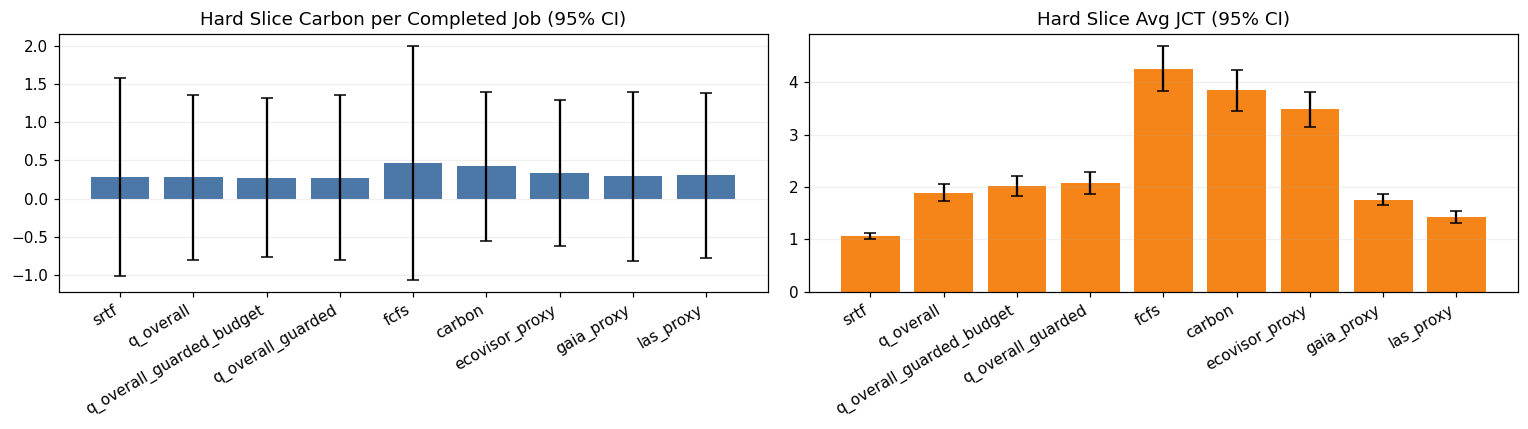

In [11]:
detail_30 = evaluate_policy_grid(
    q_table=q_final,
    df=raw_df,
    seeds=list(range(30)),
    noises=[15.0, 20.0],
    congestions=["moderate", "high"],
    capacities=[6, 8],
)

scored_30 = compute_overall_score(detail_30, best_weight_cfg)

group_cols = ["policy", "noise_pct", "congestion", "capacity"]
summary_30 = (
    scored_30.groupby(group_cols, as_index=False)
    .agg(
        n=("seed", "count"),
        carbon_mean=("carbon_kg", "mean"),
        carbon_std=("carbon_kg", "std"),
        avg_jct_mean=("avg_jct_h", "mean"),
        avg_jct_std=("avg_jct_h", "std"),
        tail_jct_mean=("tail_jct_h", "mean"),
        tail_jct_std=("tail_jct_h", "std"),
        preemptions_mean=("preemptions", "mean"),
        preemptions_std=("preemptions", "std"),
        starvation_mean=("starvation_penalty", "mean"),
        starvation_std=("starvation_penalty", "std"),
        jobs_completed_mean=("jobs_completed", "mean"),
        jobs_completed_std=("jobs_completed", "std"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_std=("overall_score", "std"),
    )
)

for metric in ["carbon", "avg_jct", "tail_jct", "preemptions", "starvation", "jobs_completed", "overall_score"]:
    std_col = f"{metric}_std"
    ci_col = f"{metric}_ci95"
    summary_30[ci_col] = 1.96 * summary_30[std_col].fillna(0.0) / np.sqrt(summary_30["n"].clip(lower=1))

summary_30["carbon_per_completed_job_mean"] = summary_30["carbon_mean"] / summary_30["jobs_completed_mean"].clip(lower=1e-9)
hard_slice = summary_30[
    (summary_30["noise_pct"] == 20.0)
    & (summary_30["congestion"] == "high")
    & (summary_30["capacity"] == 6)
].copy().sort_values("overall_score_mean")

display(hard_slice[[
    "policy",
    "overall_score_mean",
    "overall_score_ci95",
    "carbon_per_completed_job_mean",
    "avg_jct_mean",
    "tail_jct_mean",
    "jobs_completed_mean",
]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=110)
plot_df = hard_slice.copy()
x = np.arange(len(plot_df))
labels = plot_df["policy"].tolist()

axes[0].bar(x, plot_df["carbon_per_completed_job_mean"], yerr=plot_df["carbon_ci95"], capsize=4, color="#4C78A8")
axes[0].set_title("Hard Slice Carbon per Completed Job (95% CI)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(x, plot_df["avg_jct_mean"], yerr=plot_df["avg_jct_ci95"], capsize=4, color="#F58518")
axes[1].set_title("Hard Slice Avg JCT (95% CI)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha="right")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 10) Hard-Slice Significance Testing and Artifact Export

Run bootstrap pairwise comparisons in the hardest scenario and export all key artifacts.

In [12]:
hard_detail = scored_30[
    (scored_30["noise_pct"] == 20.0)
    & (scored_30["congestion"] == "high")
    & (scored_30["capacity"] == 6)
].copy()
if hard_detail.empty:
    raise ValueError("Hard-slice detail is empty; cannot run significance checks")


def bootstrap_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 4000, seed: int = 42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs = float(np.mean(a) - np.mean(b))
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.mean(sa) - np.mean(sb)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return obs, float(lo), float(hi), float(p_two)


comparisons = [
    ("q_overall", "srtf"),
    ("q_overall", "q_overall_guarded"),
    ("q_overall", "q_overall_guarded_budget"),
    ("q_overall", "carbon"),
]

sig_rows = []
for left, right in comparisons:
    a = hard_detail[hard_detail["policy"] == left]
    b = hard_detail[hard_detail["policy"] == right]
    if len(a) == 0 or len(b) == 0:
        continue

    for metric in ["carbon_per_completed_job", "avg_jct_h", "overall_score"]:
        obs, lo, hi, pval = bootstrap_diff_ci(a[metric].values, b[metric].values, n_boot=4000, seed=42)
        sig_rows.append(
            {
                "comparison": f"{left} - {right}",
                "metric": metric,
                "mean_diff": obs,
                "ci95_low": lo,
                "ci95_high": hi,
                "p_boot_two_sided": pval,
                "significant_95": not (lo <= 0.0 <= hi),
            }
        )

sig_df = pd.DataFrame(sig_rows).sort_values(["metric", "comparison"])
display(sig_df.round(6))

save_root = Path("../data")
save_root.mkdir(parents=True, exist_ok=True)

artifacts = {
    "overall_optimal_weight_sweep.csv": weight_sweep,
    "overall_optimal_guardrail_quantile_sweep.csv": q_summary,
    "overall_optimal_guard_budget_sweep.csv": budget_summary,
    "overall_optimal_detail_30seed.csv": scored_30,
    "overall_optimal_ci_summary_30seed.csv": summary_30,
    "overall_optimal_hard_slice_ranking.csv": hard_slice,
    "overall_optimal_hard_slice_significance.csv": sig_df,
}

for name, frame in artifacts.items():
    out_path = save_root / name
    frame.to_csv(out_path, index=False)
    print("Saved:", out_path)

,comparison,metric,mean_diff,ci95_low,ci95_high,p_boot_two_sided,significant_95
10,q_overall - carbon,avg_jct_h,-1.949046,-2.354411,-1.523780,0.0000,True
4,q_overall - q_overall_guarded,avg_jct_h,-0.181847,-0.451197,0.076570,0.1630,False
7,q_overall - q_overall_guarded_budget,avg_jct_h,-0.123121,-0.385273,0.134004,0.3140,False
1,q_overall - srtf,avg_jct_h,0.828056,0.660273,1.004113,0.0000,True
9,q_overall - carbon,carbon_per_completed_job,-0.154737,-0.177551,-0.130679,0.0000,True
3,q_overall - q_overall_guarded,carbon_per_completed_job,0.002928,-0.004989,0.011323,0.4870,False
6,q_overall - q_overall_guarded_budget,carbon_per_completed_job,0.002555,-0.005426,0.010791,0.5365,False
0,q_overall - srtf,carbon_per_completed_job,-0.001734,-0.010502,0.007124,0.7175,False
11,q_overall - carbon,overall_score,-0.562800,-0.587761,-0.539004,0.0000,True
5,q_overall - q_overall_guarded,overall_score,-0.018051,-0.041205,0.004359,0.1075,False


Saved: ..\data\overall_optimal_weight_sweep.csv
Saved: ..\data\overall_optimal_guardrail_quantile_sweep.csv
Saved: ..\data\overall_optimal_guard_budget_sweep.csv
Saved: ..\data\overall_optimal_detail_30seed.csv
Saved: ..\data\overall_optimal_ci_summary_30seed.csv
Saved: ..\data\overall_optimal_hard_slice_ranking.csv
Saved: ..\data\overall_optimal_hard_slice_significance.csv


In [13]:
# Compact diagnostics: best policies by hard-slice mean score and significance summary
hard_diag = hard_slice[[
    "policy",
    "overall_score_mean",
    "overall_score_ci95",
    "carbon_per_completed_job_mean",
    "avg_jct_mean",
    "tail_jct_mean",
    "jobs_completed_mean",
]].copy().sort_values("overall_score_mean")

print("Hard-slice ranking (lower overall_score_mean is better):")
display(hard_diag.round(4))

print("\nTop 3 policies by overall score:")
display(hard_diag.head(3).round(4))

if "sig_df" in globals() and not sig_df.empty:
    sig_overall = sig_df[sig_df["metric"] == "overall_score"].copy()
    print("\nPairwise significance on overall_score (q_overall vs others):")
    display(sig_overall[["comparison", "mean_diff", "ci95_low", "ci95_high", "p_boot_two_sided", "significant_95"]].round(6))
else:
    print("sig_df not available yet.")

Hard-slice ranking (lower overall_score_mean is better):


,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
68,srtf,0.1300,0.0073,0.2799,1.0648,4.9599,213.0667
44,q_overall,0.2263,0.0142,0.2780,1.8928,7.1996,207.1667
60,q_overall_guarded_budget,0.2384,0.0177,0.2755,2.0160,7.4887,206.2667
52,q_overall_guarded,0.2444,0.0180,0.2751,2.0747,7.6251,205.6333
20,fcfs,0.7629,0.0144,0.4674,4.2542,10.4436,123.1000
4,carbon,0.7891,0.0195,0.4239,3.8419,11.3629,128.9667
12,ecovisor_proxy,NaN,0.0000,0.3333,3.4816,9.1360,159.0667
28,gaia_proxy,NaN,0.0000,0.2913,1.7555,6.6006,196.0667
36,las_proxy,NaN,0.0000,0.3060,1.4282,5.5743,192.7333



Top 3 policies by overall score:


,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
68,srtf,0.1300,0.0073,0.2799,1.0648,4.9599,213.0667
44,q_overall,0.2263,0.0142,0.2780,1.8928,7.1996,207.1667
60,q_overall_guarded_budget,0.2384,0.0177,0.2755,2.0160,7.4887,206.2667



Pairwise significance on overall_score (q_overall vs others):


,comparison,mean_diff,ci95_low,ci95_high,p_boot_two_sided,significant_95
11,q_overall - carbon,-0.562800,-0.587761,-0.539004,0.0000,True
5,q_overall - q_overall_guarded,-0.018051,-0.041205,0.004359,0.1075,False
8,q_overall - q_overall_guarded_budget,-0.012046,-0.034795,0.009839,0.2740,False
2,q_overall - srtf,0.096334,0.079263,0.111796,0.0000,True


## Interpretation Guide and Next Actions

1. Use overall_optimal_hard_slice_ranking.csv as the primary leaderboard for noise=20, congestion=high, capacity=6.
2. Use overall_optimal_ci_summary_30seed.csv when writing claims and confidence statements.
3. Treat significance as strong only when the bootstrap CI excludes 0 and p-value is small.
4. If q_overall still trails SRTF on overall_score_mean, increase tail/starvation weights or move to PPO while keeping this exact evaluation harness.

## 11) Research Upgrade Pack: Objective Fidelity + Advanced Learners

This extension fixes scoring fidelity issues and adds stronger learner variants designed to close the SRTF gap:
- Robust overall-score computation for all policies (including proxies)
- Hard-slice oversampled curriculum
- Imitation warm-start from SRTF expert actions
- Double-Q learning for lower overestimation bias

In [14]:
def normalize_metric_by_scenario(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.Series:
    gmin = df.groupby(group_cols)[metric].transform("min")
    gmax = df.groupby(group_cols)[metric].transform("max")
    return np.where((gmax - gmin) > 1e-12, (df[metric] - gmin) / (gmax - gmin), 0.0)


def compute_overall_score_robust(detail: pd.DataFrame, weights: dict) -> pd.DataFrame:
    out = detail.copy()

    # Ensure starvation exists for proxy policies; use avg_wait proxy when unavailable.
    if "starvation_penalty" not in out.columns:
        out["starvation_penalty"] = np.nan
    out["starvation_penalty"] = out["starvation_penalty"].fillna(out["avg_wait_h"].fillna(0.0))

    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)

    scenario_cols = ["seed", "noise_pct", "congestion", "capacity"]
    out["n_carbon"] = normalize_metric_by_scenario(out, "carbon_per_completed_job", scenario_cols)
    out["n_avg_jct"] = normalize_metric_by_scenario(out, "avg_jct_h", scenario_cols)
    out["n_tail_jct"] = normalize_metric_by_scenario(out, "tail_jct_h", scenario_cols)
    out["n_preempt"] = normalize_metric_by_scenario(out, "preempt_per_completed_job", scenario_cols)
    out["n_starvation"] = normalize_metric_by_scenario(out, "starvation_penalty", scenario_cols)

    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out


def train_hardslice_oversampled(
    episodes: int = 220,
    alpha: float = 0.10,
    gamma: float = 0.98,
    hard_prob: float = 0.70,
    reward_weights: dict | None = None,
):
    q = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    hist = []
    rw = reward_weights or STARVATION_REWARD_CFG

    for ep in range(episodes):
        rng = np.random.default_rng(910_000 + ep)
        eps = 0.03 + (1.0 - 0.03) * np.exp(-4.0 * ep / max(1, episodes))

        if rng.random() < hard_prob:
            source = "dataset"
            congestion = "high"
            noise = float(rng.choice([20.0, 25.0, 30.0], p=[0.5, 0.3, 0.2]))
            capacity = int(rng.choice([6, 8], p=[0.8, 0.2]))
        else:
            source = "dataset" if rng.random() < 0.8 else "synthetic"
            congestion = str(rng.choice(["light", "moderate", "high"], p=[0.2, 0.5, 0.3]))
            noise = float(rng.choice([5.0, 10.0, 15.0, 20.0], p=[0.2, 0.3, 0.3, 0.2]))
            capacity = int(rng.choice([6, 8, 10], p=[0.25, 0.60, 0.15]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, source, raw_df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=rw)
        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            if rng.random() < eps:
                action = int(rng.integers(0, 5))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)
            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        hist.append({
            "episode": ep,
            "reward": ep_reward,
            "carbon_kg": m["carbon_kg"],
            "avg_jct_h": m["avg_jct_h"],
            "tail_jct_h": m["tail_jct_h"],
            "hard_episode": int(congestion == "high" and noise >= 20.0 and capacity == 6),
        })

    return q, pd.DataFrame(hist)


def collect_srtf_demonstrations(n_episodes: int = 80):
    counts = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    for ep in range(n_episodes):
        rng = np.random.default_rng(930_000 + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.4, 0.6]))
        noise = float(rng.choice([15.0, 20.0, 25.0, 30.0], p=[0.2, 0.35, 0.25, 0.2]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", raw_df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=STARVATION_REWARD_CFG)

        state = env.reset()
        done = False
        while not done:
            s = discretize_state(state)
            expert_action = 2  # srtf action
            counts[s + (expert_action,)] += 1.0
            state, _, done, _ = env.step(expert_action)
    return counts


def train_double_q_learning(
    episodes: int = 220,
    alpha: float = 0.10,
    gamma: float = 0.98,
    reward_weights: dict | None = None,
    q_init: np.ndarray | None = None,
):
    q1 = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    q2 = np.zeros_like(q1)
    if q_init is not None:
        q1 += q_init
        q2 += q_init

    rw = reward_weights or STARVATION_REWARD_CFG
    hist = []

    for ep in range(episodes):
        rng = np.random.default_rng(950_000 + ep)
        eps = 0.02 + (1.0 - 0.02) * np.exp(-4.5 * ep / max(1, episodes))

        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([15.0, 20.0, 25.0, 30.0], p=[0.15, 0.45, 0.25, 0.15]))
        capacity = int(rng.choice([6, 8], p=[0.8, 0.2]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", raw_df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=rw)

        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            q_sum = q1[s] + q2[s]
            if rng.random() < eps:
                action = int(rng.integers(0, 5))
            else:
                action = int(np.argmax(q_sum))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)

            if rng.random() < 0.5:
                a_star = int(np.argmax(q1[ns]))
                td_target = reward + (0.0 if done else gamma * float(q2[ns + (a_star,)]))
                q1[s + (action,)] += alpha * (td_target - q1[s + (action,)])
            else:
                a_star = int(np.argmax(q2[ns]))
                td_target = reward + (0.0 if done else gamma * float(q1[ns + (a_star,)]))
                q2[s + (action,)] += alpha * (td_target - q2[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        hist.append({"episode": ep, "reward": ep_reward, "carbon_kg": m["carbon_kg"], "avg_jct_h": m["avg_jct_h"], "tail_jct_h": m["tail_jct_h"]})

    return (q1 + q2) / 2.0, pd.DataFrame(hist)


# 1) Hard-slice oversampled learner
q_hard, hist_hard = train_hardslice_oversampled(episodes=220, reward_weights=STARVATION_REWARD_CFG)

# 2) Imitation warm-start from SRTF demonstrations
demo_counts = collect_srtf_demonstrations(n_episodes=90)
q_imitation_init = demo_counts / np.maximum(1.0, demo_counts.sum(axis=-1, keepdims=True))

# 3) Double-Q fine-tuning with imitation initialization
q_double, hist_double = train_double_q_learning(
    episodes=220,
    reward_weights=STARVATION_REWARD_CFG,
    q_init=q_imitation_init,
)

print("Upgrade learners trained: q_hard, q_double")

Upgrade learners trained: q_hard, q_double


## 12) Advanced Variant Benchmark (Hard/Oversampled + Double-Q + Existing Models)

Compare upgraded learners against prior policies on the same stress grid with robust scoring.

C:\Users\ANISH\AppData\Local\Temp\ipykernel_22752\276432733.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([baseline_subset, adv_detail], ignore_index=True)


,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
76,srtf,0.1281,0.0058,0.2801,1.0648,4.9599,213.0667
28,q_final_weightsweep,0.2421,0.0184,0.2750,1.8007,6.8704,207.3000
44,q_overall,0.2446,0.0141,0.2783,1.8928,7.1996,207.1667
60,q_overall_guarded_budget,0.2590,0.0188,0.2758,2.0160,7.4887,206.2667
52,q_overall_guarded,0.2652,0.0186,0.2754,2.0747,7.6251,205.6333
68,q_real_domainrand,0.2949,0.0504,0.2992,2.0563,6.8573,194.1000
36,q_hard_oversampled,0.4734,0.0346,0.3130,3.3106,8.8231,183.2000
20,q_doubleq_imitation,0.6035,0.0416,0.4004,2.4834,9.4873,142.3500
12,fcfs,0.7609,0.0151,0.4771,4.2542,10.4436,123.1000
4,carbon,0.8143,0.0177,0.4331,3.8419,11.3629,128.9667


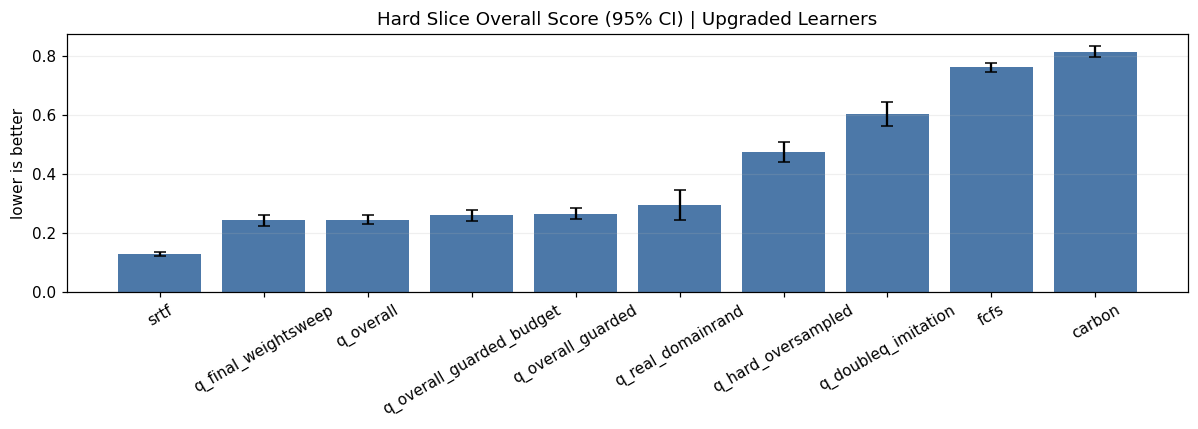

In [15]:
def evaluate_q_variant_grid(
    q_table: np.ndarray,
    policy_label: str,
    seeds: list[int],
    noises: list[float],
    congestions: list[str],
    capacities: list[int],
):
    rows = []
    for seed in seeds:
        for noise in noises:
            for cong in congestions:
                for cap in capacities:
                    row = run_policy_inference(
                        policy_name="q_overall",
                        seed=seed,
                        q_table=q_table,
                        df=raw_df,
                        noise_pct=noise,
                        congestion=cong,
                        capacity=cap,
                    )
                    row["policy"] = policy_label
                    rows.append(row)
    return pd.DataFrame(rows)


base_grid = detail_30.copy()
adv_rows = []

adv_rows.append(evaluate_q_variant_grid(q_hard, "q_hard_oversampled", list(range(20)), [15.0, 20.0], ["moderate", "high"], [6, 8]))
adv_rows.append(evaluate_q_variant_grid(q_double, "q_doubleq_imitation", list(range(20)), [15.0, 20.0], ["moderate", "high"], [6, 8]))
adv_rows.append(evaluate_q_variant_grid(q_real, "q_real_domainrand", list(range(20)), [15.0, 20.0], ["moderate", "high"], [6, 8]))
adv_rows.append(evaluate_q_variant_grid(q_final, "q_final_weightsweep", list(range(20)), [15.0, 20.0], ["moderate", "high"], [6, 8]))

adv_detail = pd.concat(adv_rows, ignore_index=True)

# Keep classic baselines from existing detail_30 for reference
baseline_subset = base_grid[base_grid["policy"].isin(["srtf", "carbon", "fcfs", "q_overall", "q_overall_guarded", "q_overall_guarded_budget"])].copy()
combined = pd.concat([baseline_subset, adv_detail], ignore_index=True)

combined_scored = compute_overall_score_robust(combined, best_weight_cfg)
combined_summary = (
    combined_scored.groupby(["policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        n=("seed", "count"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_std=("overall_score", "std"),
        carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
        avg_jct_mean=("avg_jct_h", "mean"),
        tail_jct_mean=("tail_jct_h", "mean"),
        jobs_completed_mean=("jobs_completed", "mean"),
    )
)
combined_summary["overall_score_ci95"] = 1.96 * combined_summary["overall_score_std"].fillna(0.0) / np.sqrt(combined_summary["n"].clip(lower=1))

hard_combined = combined_summary[
    (combined_summary["noise_pct"] == 20.0)
    & (combined_summary["congestion"] == "high")
    & (combined_summary["capacity"] == 6)
].copy().sort_values("overall_score_mean")

display(hard_combined[[
    "policy",
    "overall_score_mean",
    "overall_score_ci95",
    "carbon_per_completed_job_mean",
    "avg_jct_mean",
    "tail_jct_mean",
    "jobs_completed_mean",
]].round(4))

fig, ax = plt.subplots(1, 1, figsize=(11, 4), dpi=110)
ax.bar(hard_combined["policy"], hard_combined["overall_score_mean"], yerr=hard_combined["overall_score_ci95"], capsize=4, color="#4C78A8")
ax.set_title("Hard Slice Overall Score (95% CI) | Upgraded Learners")
ax.set_ylabel("lower is better")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()